In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [15]:
results_df = pd.read_csv("results_full_all.csv")

In [16]:
results_df.head()

,seed,dataset,model,optimizer,lr,classifier,translator,batch_size,num_epochs,approx_layer,mlp_linearize,attn_linearize,num_layers,original_accuracy,accuracy,delta_acc,num_samples
0,0,mnist,google/vit-base-patch16-224,Adam,0.01,Linear,linear,256,5,[],[],[],0,0.9646,0.9646,0.0000,500
1,0,mnist,google/vit-base-patch16-224,Adam,0.01,Linear,linear,256,5,[],[],[0],0,0.9646,0.9542,0.0104,500
2,0,mnist,google/vit-base-patch16-224,Adam,0.01,Linear,linear,256,5,[],[],[1],0,0.9646,0.9582,0.0064,500
3,0,mnist,google/vit-base-patch16-224,Adam,0.01,Linear,linear,256,5,[],[],[2],0,0.9646,0.9476,0.0170,500
4,0,mnist,google/vit-base-patch16-224,Adam,0.01,Linear,linear,256,5,[],[],[3],0,0.9646,0.9659,-0.0013,500


In [29]:
results_df_simp = results_df[["dataset","delta_acc","accuracy","attn_linearize"]].copy()

In [30]:
results_df_simp = results_df_simp[results_df_simp["attn_linearize"] != "[]"]
results_df_simp["attn_linearize"] = results_df_simp["attn_linearize"].apply(lambda x: int(x.strip("[]")))
results_df_simp["delta_acc"] = results_df_simp["delta_acc"] * -1

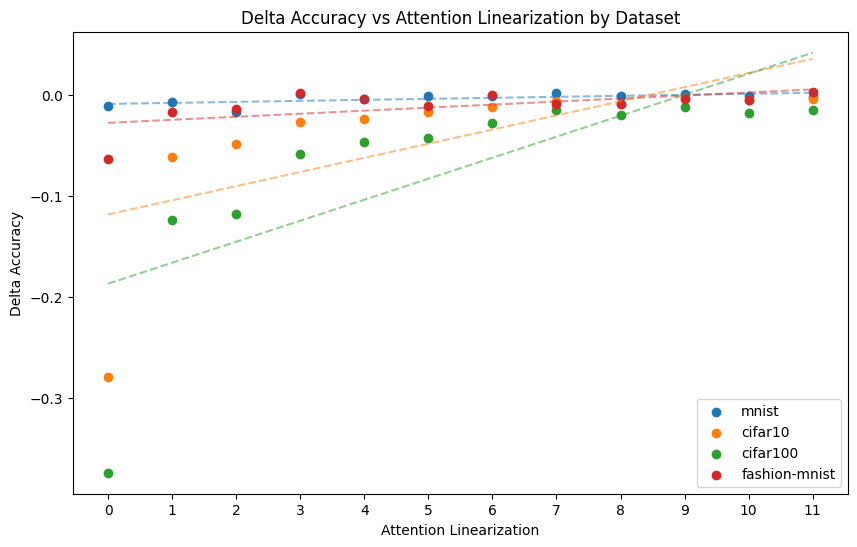

In [31]:
# plot delta_acc vs attn_linearize, colored by dataset fitting a line to each dataset
plt.figure(figsize=(10,6))
for dataset in results_df_simp["dataset"].unique():
    subset = results_df_simp[results_df_simp["dataset"] == dataset]
    plt.scatter(subset["attn_linearize"], subset["delta_acc"], label=dataset)
    z = np.polyfit(subset["attn_linearize"], subset["delta_acc"], 1)
    p = np.poly1d(z)
    plt.plot(subset["attn_linearize"], p(subset["attn_linearize"]), "--", alpha=0.5)
plt.xlabel("Attention Linearization")
plt.ylabel("Delta Accuracy")
# show every layer number on x axis
plt.xticks(results_df_simp["attn_linearize"].unique())
plt.title("Delta Accuracy vs Attention Linearization by Dataset")
plt.legend()
plt.show()

In [9]:
to_plot = results_df_simp[2:]

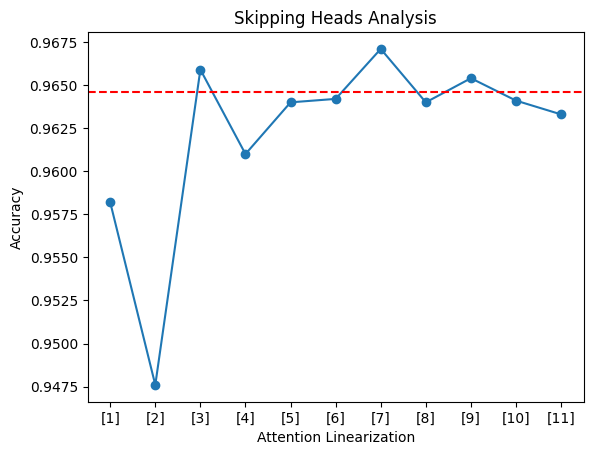

In [13]:
plt.plot(to_plot['attn_linearize'], to_plot['accuracy'], marker='o')
plt.xlabel('Attention Linearization')
plt.ylabel('Accuracy')
plt.title('Skipping Heads Analysis')
plt.axhline(y=results_df_simp['accuracy'][0], color='r', linestyle='--', label='Baseline Accuracy')
plt.show()